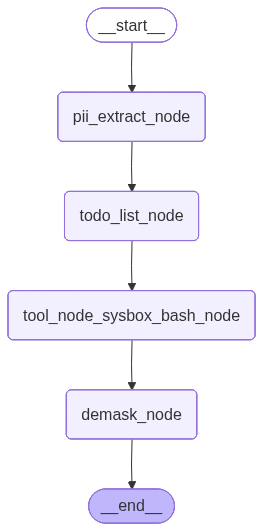

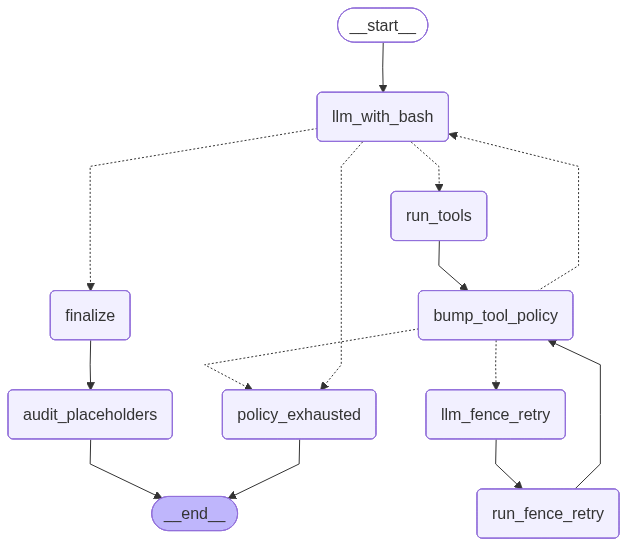

In [1]:
import os
import sys

sys.path.insert(0, "/workspace")

from src.tracing.phoenix import enable_langgraph_tracing

enable_langgraph_tracing(batch=True, verbose=False)

if not os.getenv("PHOENIX_COLLECTOR_ENDPOINT"):
    raise RuntimeError("Missing PHOENIX_COLLECTOR_ENDPOINT")
if not os.getenv("SBASH_BASE_URL"):
    raise RuntimeError("Missing SBASH_BASE_URL — is sysbox_bash healthy?")

from langchain_core.messages import HumanMessage
from langgraph.graph import END, START, StateGraph
from IPython.display import Image, display
import logging

from src.llm_nodes.global_state import GlobalState
from src.llm_nodes.pii_email.nodes import get_pii_email_node
from src.llm_nodes.todo_extract.graph import (
    build_todo_extract_subgraph,
    make_todo_extract_subgraph_runner,
)
from src.llm_nodes.tool_node_sysbox_bash.graph import (
    build_tool_node_sysbox_bash_subgraph,
    make_tool_node_sysbox_bash_subgraph_runner,
)
from src.other_nodes.demask.nodes import get_demask_node
from src.logging_setup import get_logger
from src.reducer.base_reader import BaseReducerReader
from src.reducer.reducer_session import reducer_session

# MODEL = "ollama_chat/llama3.2:3b"
# MODEL = "groq/llama-3.3-70b-versatile"
# MODEL="ollama_chat/mistral:7b"
MODEL="mistral-large-old"

pii_email = """
This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.
"""

GRAPH_RECURSION_LIMIT = 50

logger = get_logger(__name__, "assorted/session8/presentation.ipynb")
logger.setLevel(logging.DEBUG)

todo_extract_graph = build_todo_extract_subgraph(MODEL)
run_todo_extract_graph = make_todo_extract_subgraph_runner(todo_extract_graph)

tool_node_sysbox_bash_graph = build_tool_node_sysbox_bash_subgraph(MODEL)
run_tool_node_sysbox_bash_graph = make_tool_node_sysbox_bash_subgraph_runner(
    tool_node_sysbox_bash_graph
)


build_graph = StateGraph(GlobalState)

build_graph.add_node("pii_extract_node", get_pii_email_node(model=MODEL))
build_graph.add_node("todo_list_node", run_todo_extract_graph)
build_graph.add_node("tool_node_sysbox_bash_node", run_tool_node_sysbox_bash_graph)
build_graph.add_node("demask_node", get_demask_node())

build_graph.add_edge(START, "pii_extract_node")
build_graph.add_edge("pii_extract_node", "todo_list_node")
build_graph.add_edge("todo_list_node", "tool_node_sysbox_bash_node")
build_graph.add_edge("tool_node_sysbox_bash_node", "demask_node")
build_graph.add_edge("demask_node", END)

graph = build_graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
display(Image(tool_node_sysbox_bash_graph.get_graph().draw_mermaid_png()))

In [2]:
def make_reader(get_thread_id):
    return BaseReducerReader(get_thread_id=get_thread_id)


with reducer_session("Chat-sysbox-bash", factory=make_reader) as session:
    state = session.state(GlobalState, [HumanMessage(content=pii_email)])
    reply = await session.ainvoke(
        graph,
        state,
        config={"recursion_limit": GRAPH_RECURSION_LIMIT},
    )
    state = GlobalState.model_validate(reply)

    print("TODO list:")
    for k, item in enumerate(state.todo_list.items):
        print(f"  {k + 1}): who={item.who}, what={item.what}, when={item.when}")

    print("\nDeliverable (demasked by demask_node in graph):")
    print(state.final_result)

[DEBUG] [reducer/base_reader.py:51] observing message content: 
This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.

[DEBUG] [reducer/base_reader.py:51] observing message content: ```json
{"occurrences": [{"span": "ulf.wendel@ phpdoc dot de", "raw": "ulf.wendel@phpdoc.de"}, {"span": "ulf.wendel@phpdoc.de", "raw": "ulf.wendel@phpdoc.de"}, {"span": "cto@ourcompany.com", "raw": "cto@ourcompany.com"}]}
```
[DEBUG] [reducer/base_reader.py:51] observing message content: ```json
{"items": [{"who": "E0_d361152c", "what": "buy a cup of coffee", "when": "today"}, {"who": "E0_d361152c", "what": "plant a tree", "when": "tomorrow"}, {"who": "E1_d361152c", "what": "reach out to all employees regarding the current coffee shortage", 

TODO list:
  1): who=E0_d361152c, what=buy a cup of coffee, when=today
  2): who=E0_d361152c, what=plant a tree, when=tomorrow
  3): who=E1_d361152c, what=reach out to all employees regarding the current coffee shortage, when=today

Deliverable (demasked by demask_node in graph):
---

# ulf.wendel@phpdoc.de
- [ ] coffee of cup a buy (5 words) (by today)
  ```
   ( (
    ) )
 ........
 |      | ]
 \______/

  sandbox probe — Kernel version of the sandbox: 7.0.12-1-default
  ```

- [ ] tree a plant (3 words) (by tomorrow)
  ```
     *
    ***
   *****
  *******
     |

  sandbox probe — Number of CPU cores available in the sandbox: 10
  ```

---

# cto@ourcompany.com
- [ ] shortage coffee current the regarding employees all to out reach (10 words) (by today)
  ```
   ( (
    ) )
 ........
 |      | ]
 \______/
     |
     |
    / \

  sandbox probe — Current working directory path: /sandbox/session
  ```
